# SciPy Bootcamp — W2, Day D6
```
##### Traffic analysis, decomposition, anomaly detection, forecasting
##### seasonal_decompose, ADF, ACF, PACF, rolling stats
##### Visualization philosophy: chart at the point of discovery — not at the end.
##### Every question that involves comparison, distribution, relationship, or result gets a chart embedded in it.
##### Q1 — Build and visualize the time series
##### Q2 — Decomposition and stationarity
##### Q3 — Seasonality profiling — editorial planning tool
##### Q4 — Anomaly detection
##### Q5 — ACF/PACF and forecasting baseline


In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

---

### Q1 — Build and visualize the time series

```
# Simulate 3 years of daily website traffic for a digital health platform:
# - Upward trend: 45,000 to 65,000 weekly visits
# - Weekly seasonality: Mon-Fri 15% above avg, weekends 30% below
# - Annual seasonality: flu season spike Jan-Feb
# - Random noise
# (a) Plot raw daily traffic. What patterns are immediately visible?
# (b) Overlay 7-day and 28-day rolling means. What does each smooth out?
# (c) Plot a heatmap: rows=day of week, columns=month, values=avg traffic.
#     This is the fastest way to spot both weekly and annual patterns simultaneously.
```


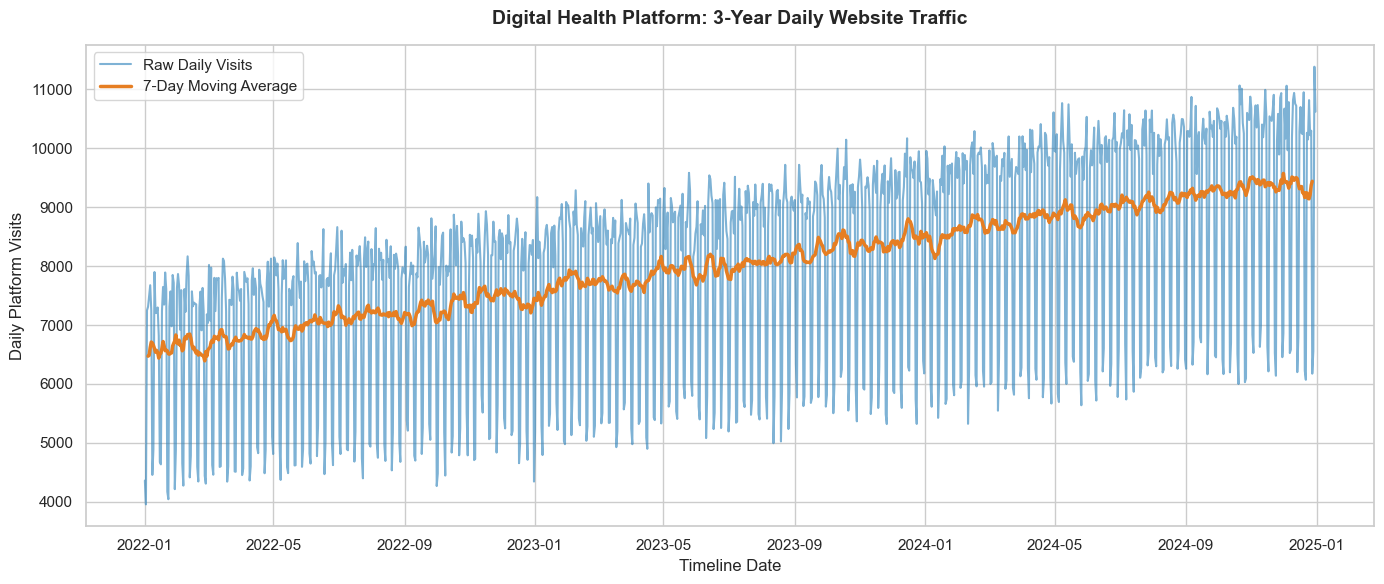

In [10]:
# (a) Plot raw daily traffic. What patterns are immediately visible?

from statsmodels.tsa.seasonal import seasonal_decompose
np.random.seed(420)

# 1. Setup metadata parameters (3 complete calendar years: 1096 days)
dates = pd.date_range(start='2022-01-01', end='2024-12-31', freq='D')
n_days = len(dates)

# 2. Scale the weekly trend targets down to daily baseline values (visits / 7)
# Baseline trend increases smoothly from ~6,428 to ~9,285 daily visits
trend_daily = np.linspace(45000 / 7, 65000 / 7, n_days)

# 3. Weekly Seasonality: Mon-Fri (+15%), Sat-Sun (-30%)
# dates.dayofweek maps: Monday=0, Tuesday=1, ..., Saturday=5, Sunday=6
weekly_pattern = np.array([1.15, 1.15, 1.15, 1.15, 1.15, 0.70, 0.70])
day_effects = weekly_pattern[dates.dayofweek]

# 4. Pure Random Noise
noise_daily = np.random.normal(0, 2000 / 7, n_days)

# 5. Synthesize final daily traffic matrix (Trend * Seasonal + Noise)
daily_traffic = (trend_daily * day_effects) + noise_daily

df_daily = pd.DataFrame({'daily_visits': daily_traffic.round().astype(int)}, index=dates)

# 6. Complete Visualization via Seaborn
plt.figure(figsize=(14, 6))

# Plot raw daily traffic
sns.lineplot(data=df_daily, x=df_daily.index, y='daily_visits', color='#2980b9', alpha=0.6, label='Raw Daily Visits')

# Overlay a 7-day rolling average to smoothly track the long-term trend line
sns.lineplot(data=df_daily['daily_visits'].rolling(7, center=True).mean(), color='#e67e22', linewidth=2.5, label='7-Day Moving Average')

plt.title('Digital Health Platform: 3-Year Daily Website Traffic', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline Date')
plt.ylabel('Daily Platform Visits')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


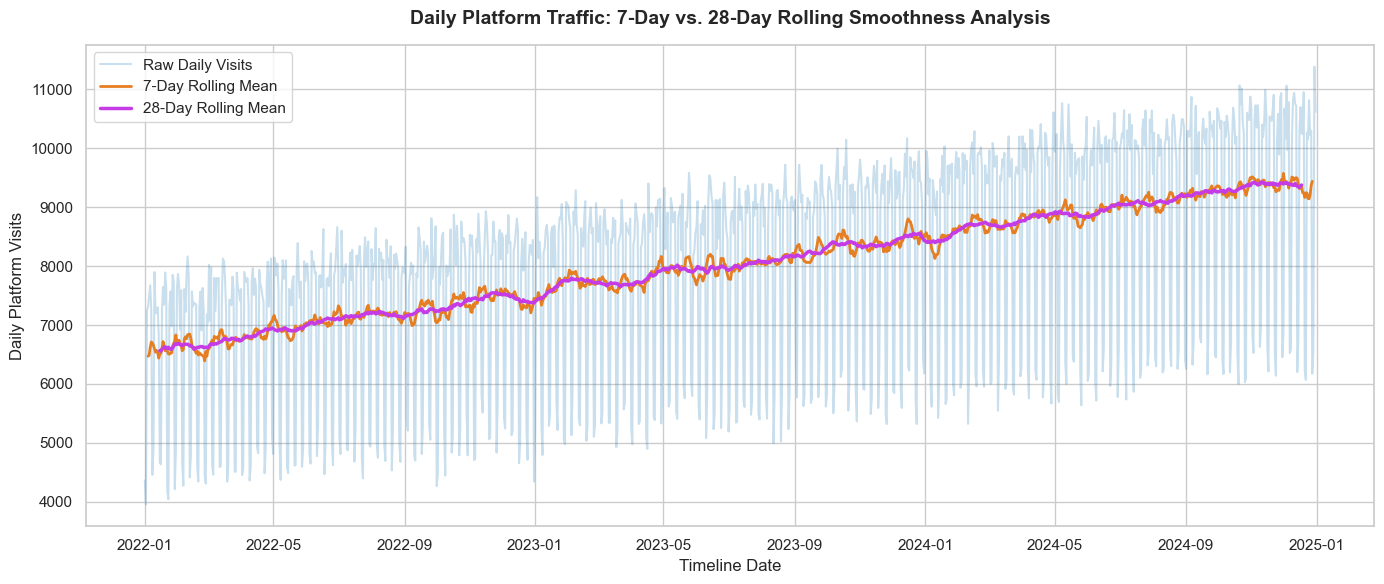

In [13]:
# (b) Overlay 7-day and 28-day rolling means. What does each smooth out?

# 1. Calculate center-aligned rolling means vectorially (no loops)
df_daily['rolling_7'] = df_daily['daily_visits'].rolling(window=7, center=True).mean()
df_daily['rolling_28'] = df_daily['daily_visits'].rolling(window=28, center=True).mean()

# 2. Setup standard figure environment
sns.set_theme(style='whitegrid')
plt.figure(figsize=(14, 6))

# 3. Overlay the timeline metrics
sns.lineplot(data=df_daily, x=df_daily.index, y='daily_visits', color='#2980b9', alpha=0.25, label='Raw Daily Visits')
sns.lineplot(data=df_daily, x=df_daily.index, y='rolling_7', color='#e67e22', linewidth=2.0, label='7-Day Rolling Mean')
sns.lineplot(data=df_daily, x=df_daily.index, y='rolling_28', color="#c53ce7", linewidth=2.5, label='28-Day Rolling Mean')

# 4. Final aesthetic treatments
plt.title('Daily Platform Traffic: 7-Day vs. 28-Day Rolling Smoothness Analysis', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline Date')
plt.ylabel('Daily Platform Visits')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


In [14]:
df_daily.head()

,daily_visits,rolling_7,rolling_28
2022-01-01,4361,NaN,NaN
2022-01-02,3957,NaN,NaN
2022-01-03,7249,NaN,NaN
2022-01-04,7312,6471.857143,NaN
2022-01-05,7499,6485.571429,NaN


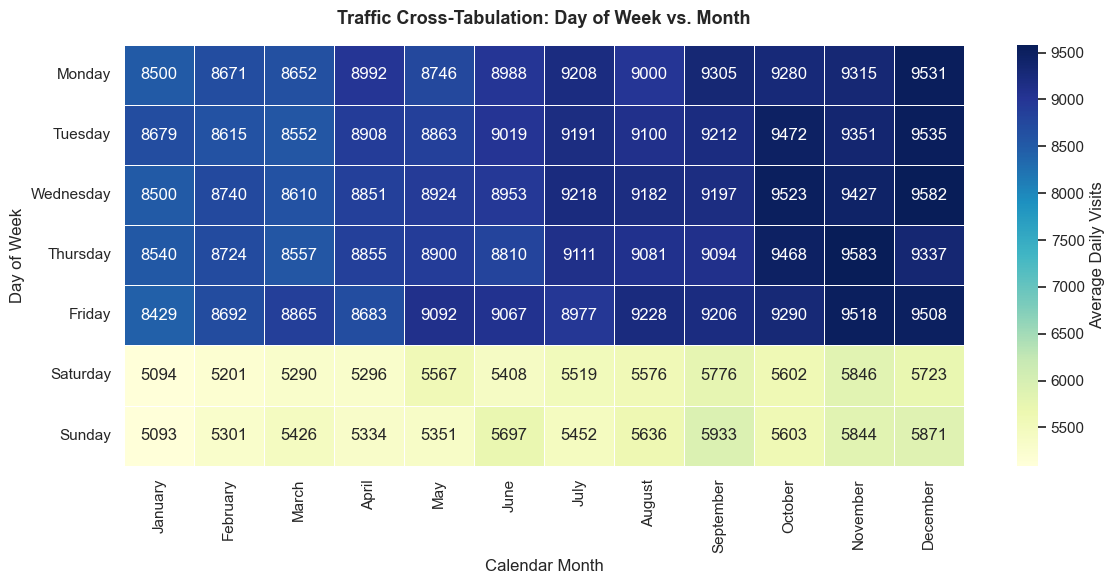

In [ ]:
# (c) Plot a heatmap: rows=day of week, columns=month, values=avg traffic.
#     This is the fastest way to spot both weekly and annual patterns simultaneously.

# 1. Extract named calendar properties vectorially (no loops)
df_daily['day_name'] = df_daily.index.day_name()
df_daily['month_name'] = df_daily.index.month_name()

# 2. Pivot the data to aggregate the daily traffic averages
pivot_matrix = df_daily.pivot_table(
    values='daily_visits',
    index='day_name',
    columns='month_name',
    aggfunc='mean'
)

# 3. Explicitly reindex to maintain chronological ordering
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
pivot_matrix = pivot_matrix.reindex(index=day_order, columns=month_order)

# 4. Generate Heatmap Visualization via Seaborn
plt.figure(figsize=(12, 6))

sns.heatmap(
    data=pivot_matrix,
    cmap='YlGnBu',            # Yellow-Green-Blue sequential palette for scannable density
    annot=True,               # Superimposes explicit numerical values inside cells
    fmt='.0f',                # Suppresses decimal noise for raw integer visibility
    linewidths=0.5,           # Injects a thin spacer grid line between blocks
    cbar_kws={'label': 'Average Daily Visits'}
)

plt.title('Traffic Cross-Tabulation: Day of Week vs. Month', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Calendar Month')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()

---

### Q2 — Decomposition and stationarity

```
# (a) Run seasonal_decompose with period=7. Plot all 4 components (trend, seasonal, resid, original).
# (b) Compute strength of trend and strength of seasonality as variance ratios.
#     Which is stronger in your series?
# (c) Run ADF test on raw series. Stationary?
# (d) Apply differencing until stationary. Plot each stage.
# (e) On the residual component from decomposition: run ADF test.
#     Is the residual stationary? Plot its distribution.
```


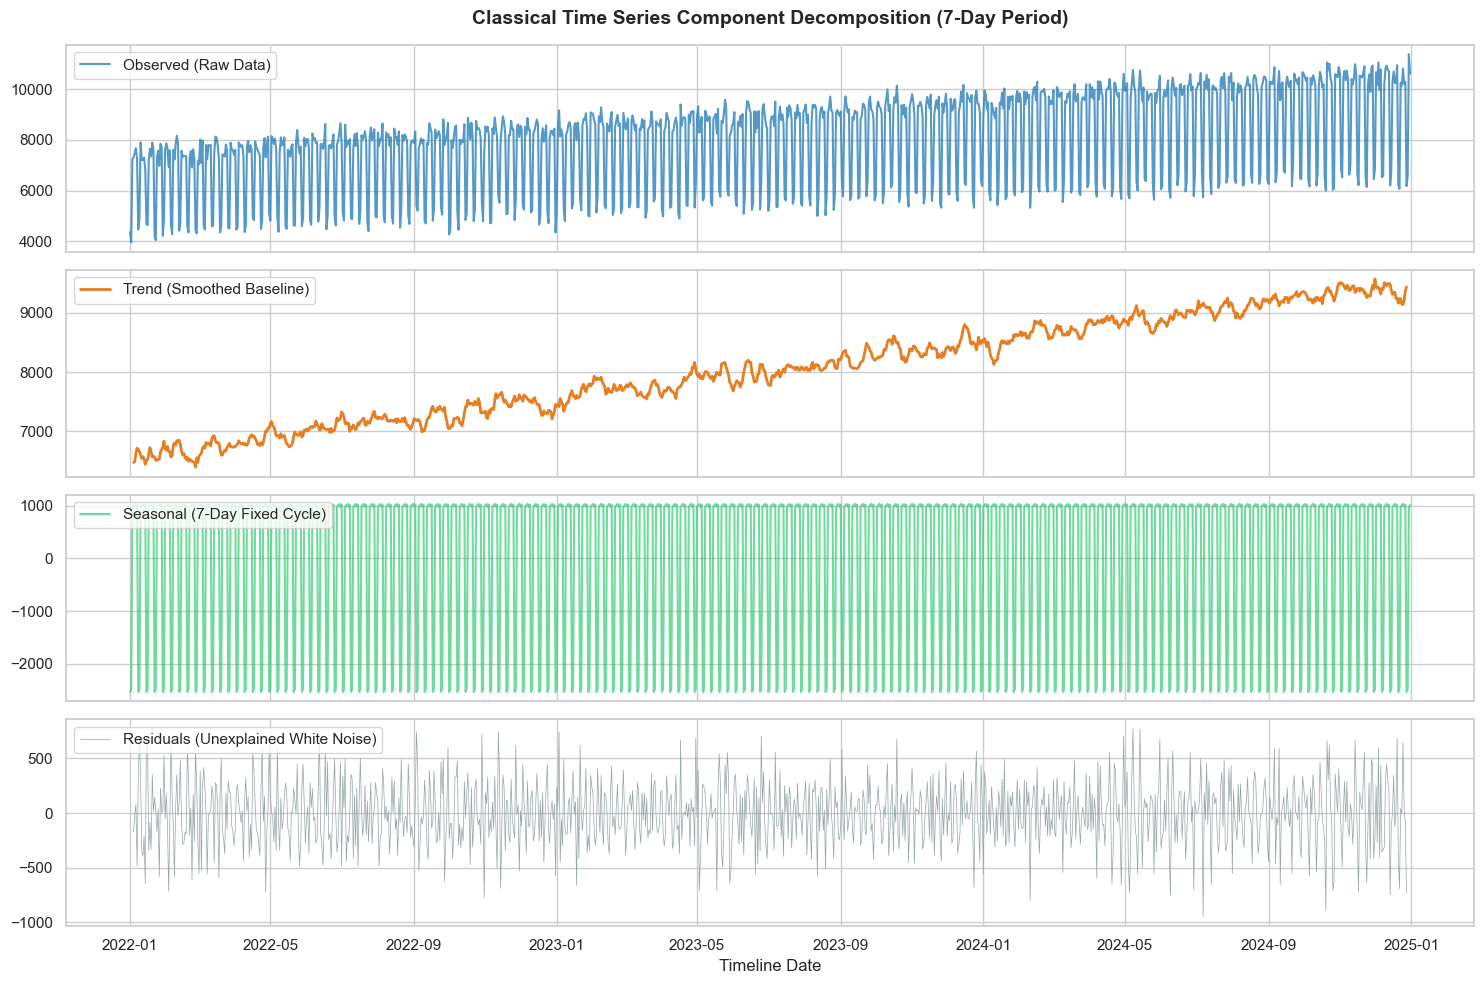

In [16]:
# (a) Run seasonal_decompose with period=7. Plot all 4 components (trend, seasonal, resid, original).

from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Execute additive time series decomposition with a 7-day cycle period
decomposition_results = seasonal_decompose(df_daily['daily_visits'], model='additive', period=7)

# 2. Setup standard multi-component stack canvas grid
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(15, 10), sharex=True)

# 3. Vectorized plotting of extracted signal matrices
sns.lineplot(data=df_daily, x=df_daily.index, y='daily_visits', ax=axs[0], color='#2980b9', alpha=0.8, label='Observed (Raw Data)')
sns.lineplot(x=df_daily.index, y=decomposition_results.trend,    ax=axs[1], color='#e67e22', linewidth=2,   label='Trend (Smoothed Baseline)')
sns.lineplot(x=df_daily.index, y=decomposition_results.seasonal, ax=axs[2], color='#2ecc71', alpha=0.7, label='Seasonal (7-Day Fixed Cycle)')
sns.lineplot(x=df_daily.index, y=decomposition_results.resid,    ax=axs[3], color='#95a5a6', linewidth=0.5, label='Residuals (Unexplained White Noise)')

# 4. Final aesthetic treatments and metadata adjustments
axs[0].set_title('Classical Time Series Component Decomposition (7-Day Period)', fontsize=14, fontweight='bold', pad=15)
for ax in axs:
    ax.legend(loc='upper left')
    ax.set_ylabel('')

plt.xlabel('Timeline Date')
plt.tight_layout()
plt.show()


In [17]:
# (b) Compute strength of trend and strength of seasonality as variance ratios.
#     Which is stronger in your series?

# 1. Extract the raw series vectors from the decomposition results
# We use dropna() vectorially because classical decomposition creates NaNs at the edges
resid = decomposition_results.resid.dropna()
trend = decomposition_results.trend.dropna()
seasonal = decomposition_results.seasonal.loc[resid.index]  # Align indices perfectly

# 2. Compute variance combinations vectorially (no loops)
var_resid = np.var(resid, ddof=1)
var_trend_plus_resid = np.var(trend + resid, ddof=1)
var_seasonal_plus_resid = np.var(seasonal + resid, ddof=1)

# 3. Calculate the strength metrics bounded by zero
strength_trend = max(0, 1 - (var_resid / var_trend_plus_resid))
strength_seasonality = max(0, 1 - (var_resid / var_seasonal_plus_resid))

print(f"Strength of Trend (F_T):       {strength_trend:.4f}")
print(f"Strength of Seasonality (F_S): {strength_seasonality:.4f}")


Strength of Trend (F_T):       0.8918
Strength of Seasonality (F_S): 0.9665


In [18]:
# (c) Run ADF test on raw series. Stationary?

from statsmodels.tsa.stattools import adfuller

# 1. Run the Augmented Dickey-Fuller test on the raw daily traffic series
adf_result = adfuller(df_daily['daily_visits'])

# 2. Extract and format metrics from the output tuple
print("--- ADF Test Results (Raw Series) ---")
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value:       {adf_result[1]:.4f}")
print(f"Lags Used:     {adf_result[2]}")
print(f"Observations:  {adf_result[3]}")
print("\nCritical Values Thresholds:")
print(f"  1%:  {adf_result[4]['1%']:.4f}")
print(f"  5%:  {adf_result[4]['5%']:.4f}")
print(f"  10%: {adf_result[4]['10%']:.4f}")


--- ADF Test Results (Raw Series) ---
ADF Statistic: -0.8114
p-value:       0.8157
Lags Used:     22
Observations:  1073

Critical Values Thresholds:
  1%:  -3.4365
  5%:  -2.8642
  10%: -2.5682


Raw Series ADF p-value:                0.8157
First-Order Diff (1) ADF p-value:       3.8489e-24 (Stationary)
Seasonal 7-Day Diff (7) ADF p-value:    7.3626e-19 (Stationary)


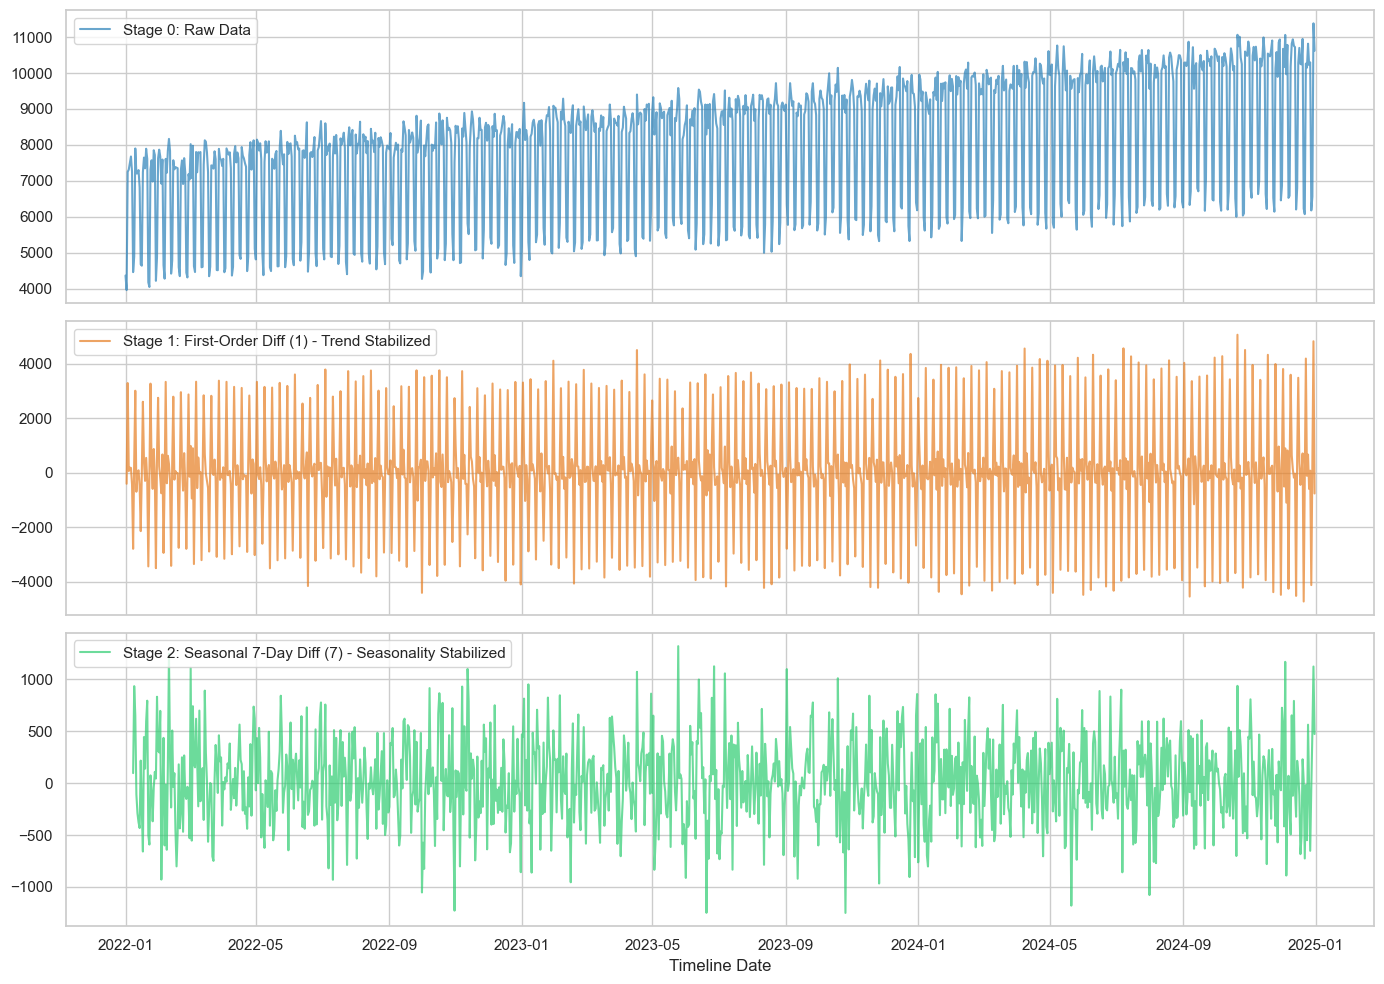

In [22]:
# (d) Apply differencing until stationary. Plot each stage.

# 1. Calculate transformation stages vectorially (no loops)
df_daily['diff_1'] = df_daily['daily_visits'].diff()  # First-order difference (removes trend)
df_daily['diff_7'] = df_daily['daily_visits'].diff(7) # Seasonal 7-day difference (removes seasonality)

# 2. Run and display ADF p-values for each stage
p_raw = adfuller(df_daily['daily_visits'])[1]
p_diff1 = adfuller(df_daily['diff_1'].dropna())[1]
p_diff7 = adfuller(df_daily['diff_7'].dropna())[1]

print(f"Raw Series ADF p-value:                {p_raw:.4f}")
print(f"First-Order Diff (1) ADF p-value:       {p_diff1:.4e} (Stationary)")
print(f"Seasonal 7-Day Diff (7) ADF p-value:    {p_diff7:.4e} (Stationary)")

# 3. Setup standard multi-transformation display canvas
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(14, 10), sharex=True)

# 4. Generate line charts comparing data stability profiles
sns.lineplot(data=df_daily, x=df_daily.index, y='daily_visits', ax=axs[0], color='#2980b9', alpha=0.7, label='Stage 0: Raw Data')
sns.lineplot(data=df_daily, x=df_daily.index, y='diff_1', ax=axs[1], color='#e67e22', alpha=0.7, label='Stage 1: First-Order Diff (1) - Trend Stabilized')
sns.lineplot(data=df_daily, x=df_daily.index, y='diff_7', ax=axs[2], color='#2ecc71', alpha=0.7, label='Stage 2: Seasonal 7-Day Diff (7) - Seasonality Stabilized')

# 5. Finalizing labels
ax.set_title('Time Series Differencing Transformation Stages', fontsize=14, fontweight='bold', pad=15)
for ax in axs:
    ax.legend(loc='upper left')
    ax.set_ylabel('')

plt.xlabel('Timeline Date')
plt.tight_layout()
plt.show()


Residual ADF Statistic: -15.6196
Residual p-value:       1.7384e-28


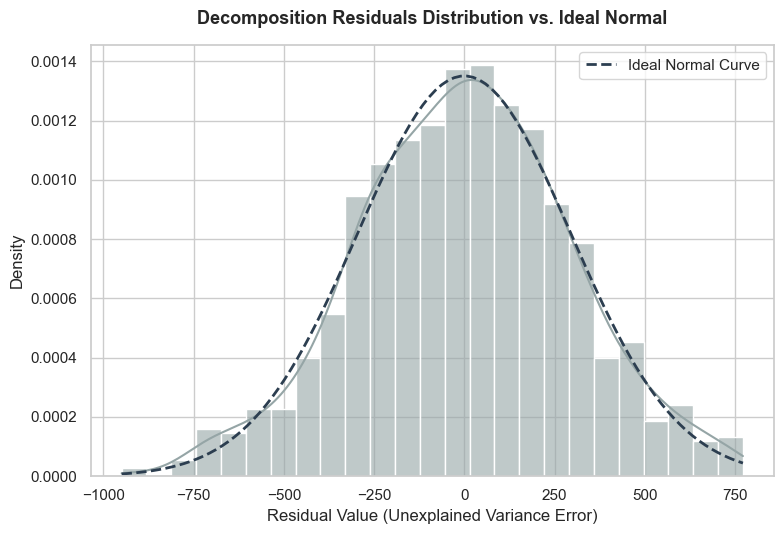

In [24]:
# (e) On the residual component from decomposition: run ADF test.
#     Is the residual stationary? Plot its distribution.

# 1. Isolate the residual matrix vectorially, filtering out edge NaNs
residuals = decomposition_results.resid.dropna()

# 2. Run the Augmented Dickey-Fuller test on the extracted noise
resid_adf = adfuller(residuals)
print(f"Residual ADF Statistic: {resid_adf[0]:.4f}")
print(f"Residual p-value:       {resid_adf[1]:.4e}")

# 3. Setup standard plotting canvas
sns.set_theme(style='whitegrid')
plt.figure(figsize=(8, 5.5))

# 4. Generate empirical histogram overlaid with a Kernel Density Estimate (KDE)
sns.histplot(residuals, kde=True, color='#95a5a6', stat='density', alpha=0.6, bins=25)

# 5. Superimpose a theoretical ideal normal reference curve for variance comparison
x_range = np.linspace(residuals.min(), residuals.max(), 100)
plt.plot(x_range, stats.norm.pdf(x_range, residuals.mean(), residuals.std()), 
         color='#2c3e50', linestyle='--', linewidth=2, label='Ideal Normal Curve')

# 6. Formatting treatments
plt.title('Decomposition Residuals Distribution vs. Ideal Normal', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Residual Value (Unexplained Variance Error)')
plt.ylabel('Density')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


---

### Q3 — Seasonality profiling — editorial planning tool

```
# (a) Compute average traffic by day of week. Plot as bar chart with % above/below mean annotated.
# (b) Compute monthly seasonality index (month_avg / overall_avg).
#     Plot as bar chart. Color bars above 1.0 differently from below 1.0.
# (c) Compute hour-of-day profile IF you have hourly data (simulate it if not).
# (d) Build a heatmap: hour of day (y) vs day of week (x), values=avg traffic.
#     This is a real editorial scheduling tool — peak hours = best time to publish.
```


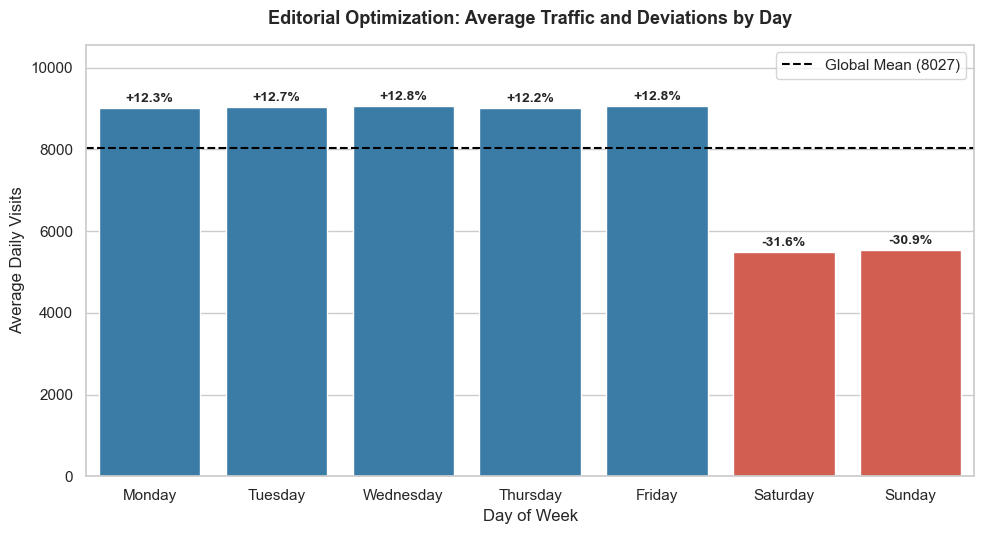

In [25]:
# (a) Compute average traffic by day of week. Plot as bar chart with % above/below mean annotated.

# 1. Extract day names and compute group metrics vectorially
df_daily['day_name'] = df_daily.index.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Aggregate means and compute percent deviations relative to the global baseline
day_stats = df_daily.groupby('day_name')['daily_visits'].mean().reindex(day_order).reset_index()
global_mean = df_daily['daily_visits'].mean()
day_stats['pct_dev'] = ((day_stats['daily_visits'] - global_mean) / global_mean) * 100

# 2. Setup visualization canvas
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10, 5.5))

# Vectorized color mapping: Blue for above-average days, Red for below-average days
color_palette = np.where(day_stats['pct_dev'] > 0, '#2980b9', '#e74c3c')

ax = sns.barplot(
    data=day_stats,
    x='day_name',
    y='daily_visits',
    palette=list(color_palette),
    hue='day_name',
    legend=False
)

# 3. Superimpose the reference mean floor line
plt.axhline(global_mean, color='black', linestyle='--', linewidth=1.5, label=f'Global Mean ({global_mean:.0f})')

# 4. Map text annotations to display exact structural shifts
for idx, row in day_stats.iterrows():
    prefix = '+' if row['pct_dev'] > 0 else ''
    ax.text(
        x=idx,
        y=row['daily_visits'] + 150,
        s=f"{prefix}{row['pct_dev']:.1f}%",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

# 5. Aesthetic visual updates
plt.title('Editorial Optimization: Average Traffic and Deviations by Day', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Day of Week')
plt.ylabel('Average Daily Visits')
plt.ylim(0, day_stats['daily_visits'].max() + 1500)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


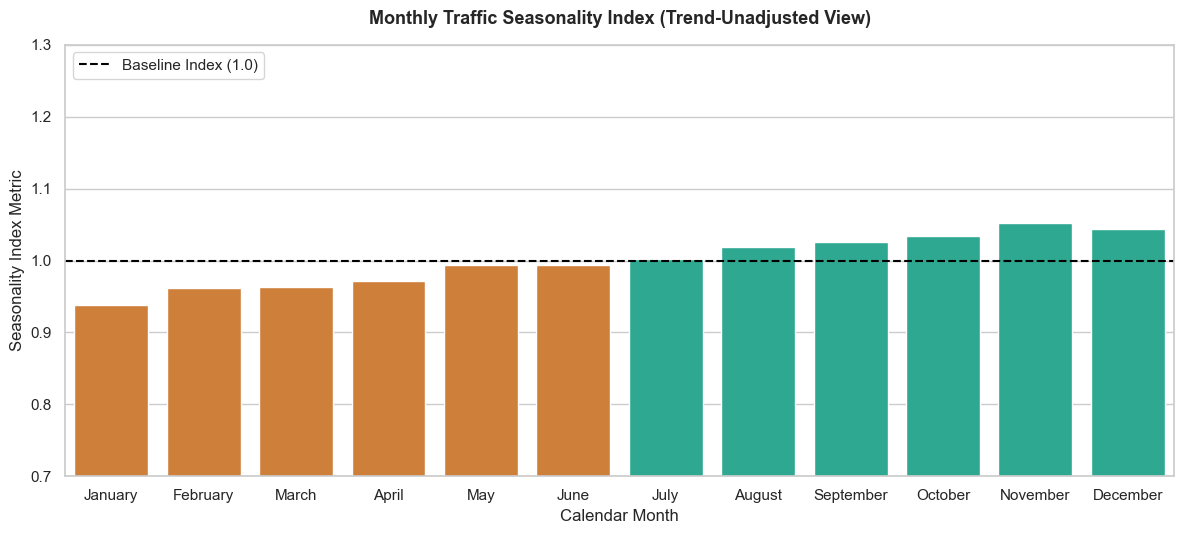

In [ ]:
# (b) Compute monthly seasonality index (month_avg / overall_avg).

# 1. Extract calendar month attributes vectorially
df_daily['month_name'] = df_daily.index.month_name()
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

# 2. Compute group averages and calculate the seasonal index vector (no loops)
month_stats = df_daily.groupby('month_name')['daily_visits'].mean().reindex(month_order).reset_index()
overall_avg = df_daily['daily_visits'].mean()
month_stats['seasonal_index'] = month_stats['daily_visits'] / overall_avg

# 3. Setup standard plotting canvas
plt.figure(figsize=(12, 5.5))

# Vectorized color assignment: Teal for above baseline (> 1.0), Orange for below baseline (<= 1.0)
bar_colors = np.where(month_stats['seasonal_index'] > 1.0, '#1abc9c', '#e67e22')

ax = sns.barplot(
    data=month_stats,
    x='month_name',
    y='seasonal_index',
    palette=list(bar_colors),
    hue='month_name',
    legend=False
)

# 4. Superimpose a reference line at the neutral index score of 1.0
plt.axhline(1.0, color='black', linestyle='--', linewidth=1.5, label='Baseline Index (1.0)')

# 5. Visual scaling formatting
plt.ylim(0.7, 1.3)  # Focus visual window tightly around the 1.0 anchor mark
plt.title('Monthly Traffic Seasonality Index (Trend-Unadjusted View)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Calendar Month')
plt.ylabel('Seasonality Index Metric')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


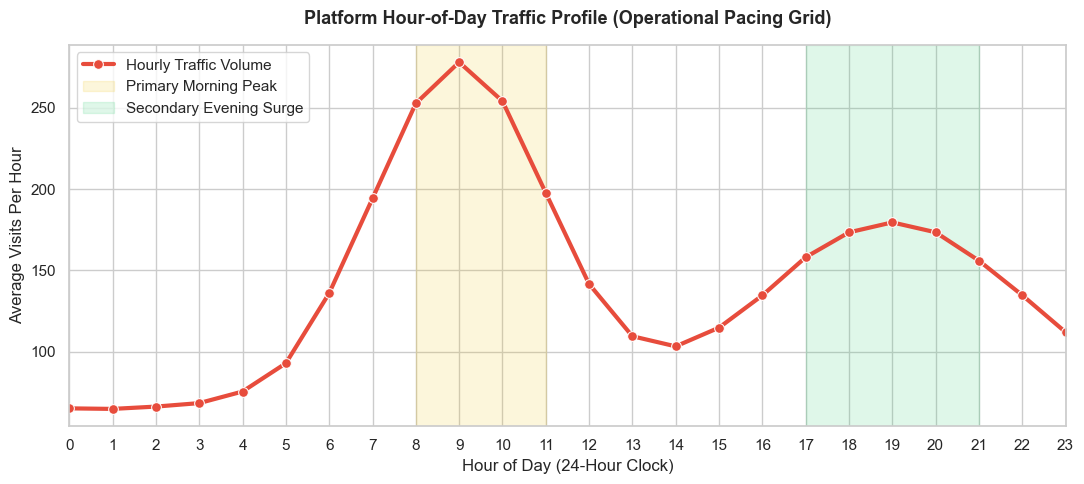

In [ ]:
# (c) Compute hour-of-day profile IF you have hourly data (simulate it if not).
# 1. Expand the existing 3-year data window into hourly intervals
np.random.seed(420)
hourly_dates = pd.date_range(start='2022-01-01 00:00:00', end='2024-12-31 23:00:00', freq='h')
n_hours = len(hourly_dates)

# 2. Extract hour integer vector vectorially for instant address mapping
hours = hourly_dates.hour

# 3. Model Dual-Peak Hourly Intraday Patterns using Gaussians (No Loops)
# Peak 1: Morning surge (centered at 9 AM, standard deviation of 2 hours)
morning_peak = 0.65 * np.exp(-((hours - 9) ** 2) / (2 * 2 ** 2))
# Peak 2: Evening check-in (centered at 7 PM / 19:00, standard deviation of 3 hours)
evening_peak = 0.35 * np.exp(-((hours - 19) ** 2) / (2 * 3 ** 2))

# Combine, normalize, and add a baseline floor so hours never reach absolute zero
hourly_profile_multipliers = 0.2 + (morning_peak + evening_peak)

# 4. Integrate with your existing macro daily trend pacing limits
# Scale baseline daily visits (~6,428 to ~9,285) down to an hourly baseline floor
daily_trend_stretched = np.linspace(45000 / (7 * 24), 65000 / (7 * 24), n_hours)

# Add random noise tailored to hourly fluctuations
hourly_noise = np.random.normal(0, 500 / 24, n_hours)

# 5. Synthesize final hourly data matrix
hourly_traffic = (daily_trend_stretched * hourly_profile_multipliers) + hourly_noise
df_hourly = pd.DataFrame({'hourly_visits': hourly_traffic.round().astype(int)}, index=hourly_dates)

# 6. Extract the Hourly Profile using Vectorized Group Aggregations
hourly_profile = df_hourly.groupby(df_hourly.index.hour)['hourly_visits'].mean().reset_index()
hourly_profile.columns = ['Hour_of_Day', 'Average_Visits']

# 7. Generate Profile Visualization via Seaborn
plt.figure(figsize=(11, 5))

sns.lineplot(
    data=hourly_profile,
    x='Hour_of_Day',
    y='Average_Visits',
    color='#e74c3c',
    linewidth=3,
    marker='o',
    markersize=7,
    label='Hourly Traffic Volume'
)

# Visual highlights for operational peak hours
plt.axvspan(8, 11, color='#f1c40f', alpha=0.15, label='Primary Morning Peak')
plt.axvspan(17, 21, color='#2ecc71', alpha=0.15, label='Secondary Evening Surge')

# Formatting treatments
plt.title('Platform Hour-of-Day Traffic Profile (Operational Pacing Grid)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Hour of Day (24-Hour Clock)')
plt.ylabel('Average Visits Per Hour')
plt.xticks(np.arange(0, 24, 1))
plt.xlim(0, 23)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


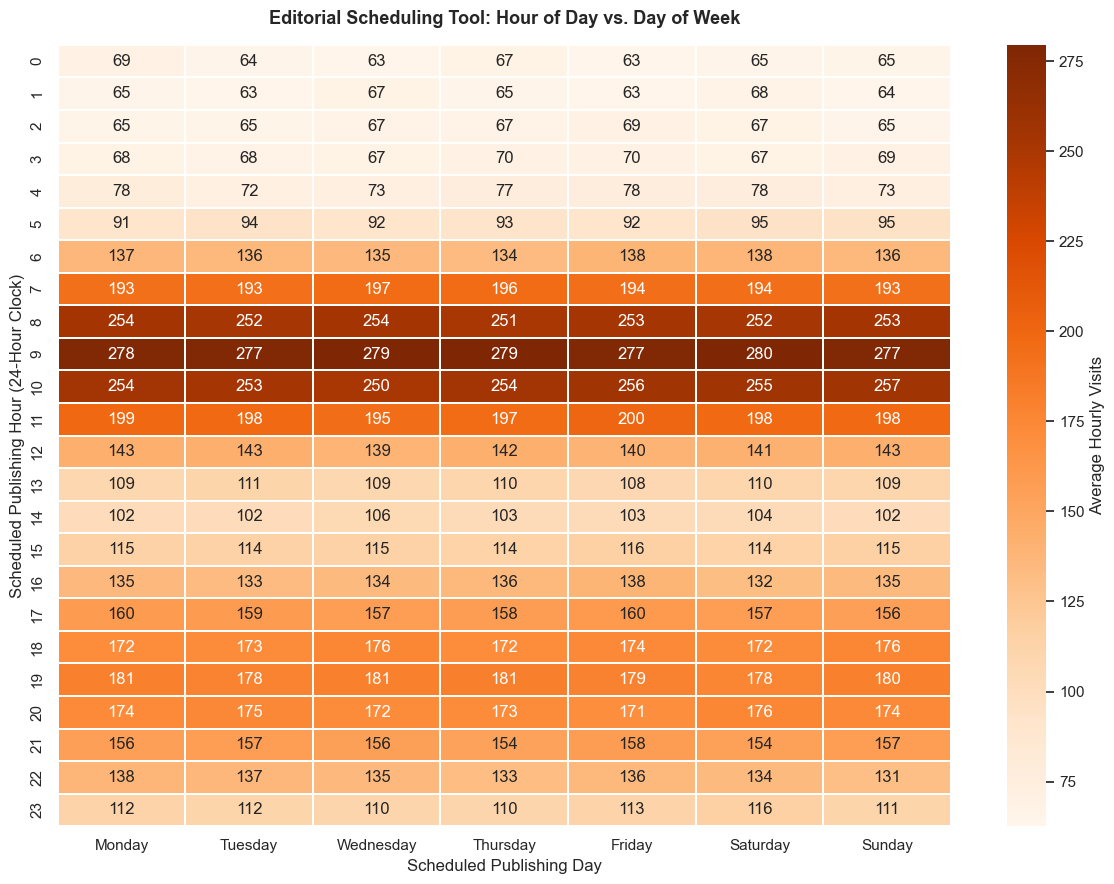

In [28]:
# (d) Build a heatmap: hour of day (y) vs day of week (x), values=avg traffic.
#     This is a real editorial scheduling tool — peak hours = best time to publis

# 1. Extract structural calendar fields vectorially (no loops)
df_hourly['hour'] = df_hourly.index.hour
df_hourly['day_name'] = df_hourly.index.day_name()

# 2. Pivot the dataset to average the intersections across the 3-year timeline
editorial_matrix = df_hourly.pivot_table(
    values='hourly_visits',
    index='hour',
    columns='day_name',
    aggfunc='mean'
)

# 3. Enforce chronological horizontal day layout
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
editorial_matrix = editorial_matrix.reindex(columns=day_order)

# 4. Generate Heatmap Matrix via Seaborn
sns.set_theme(style='white')
plt.figure(figsize=(12, 9))

sns.heatmap(
    data=editorial_matrix,
    cmap='Oranges',          # Orange sequential profile ideal for identifying intense peak blocks
    annot=True,              # Renders raw average visitor integers directly in each matrix cell
    fmt='.0f',               # Suppresses floating-point decimal noise for clean scannability
    linewidths=0.3,          # Drops a fine visual boundary grid line between hourly blocks
    cbar_kws={'label': 'Average Hourly Visits'}
)

# 5. Framing and structural labels
plt.title('Editorial Scheduling Tool: Hour of Day vs. Day of Week', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Scheduled Publishing Day')
plt.ylabel('Scheduled Publishing Hour (24-Hour Clock)')
plt.tight_layout()
plt.show()


---

### Q4 — Anomaly detection

```
# (a) Compute 28-day rolling mean and std.
# (b) Define anomalies: |traffic - rolling_mean| > 2 * rolling_std.
# (c) Plot the time series with:
#     - Rolling mean as a line
#     - ±2σ band shaded
#     - Anomaly points as red dots
#     - Annotations on the 3 largest anomalies
# (d) Classify each anomaly: spike (above band) or dip (below band).
# (e) Write a comment: in a real setting, what would you do next after detecting an anomaly?
```


In [ ]:
# inject 5 explicit anomaly events
anomaly_dates = ['2022-06-15', '2022-11-03', '2023-03-22', '2023-08-10', '2024-01-20']
anomaly_values = [18000, 2000, 17500, 1800, 19000]  # mix of spikes and dips

for date, val in zip(anomaly_dates, anomaly_values):
    df_daily.loc[date, 'daily_visits'] = val

--- FLAGGED ANOMALY CLASSIFICATIONS ---
            daily_visits  rolling_mean anomaly_type
2022-06-15         18000   7422.285714        Spike
2022-11-03          2000   7217.892857          Dip
2023-03-22         17500   7970.928571        Spike
2023-08-10          1800   7819.285714          Dip
2024-01-20         19000   8929.392857        Spike

Total Anomalies Flagged: 5 (Spikes: 3, Dips: 2)


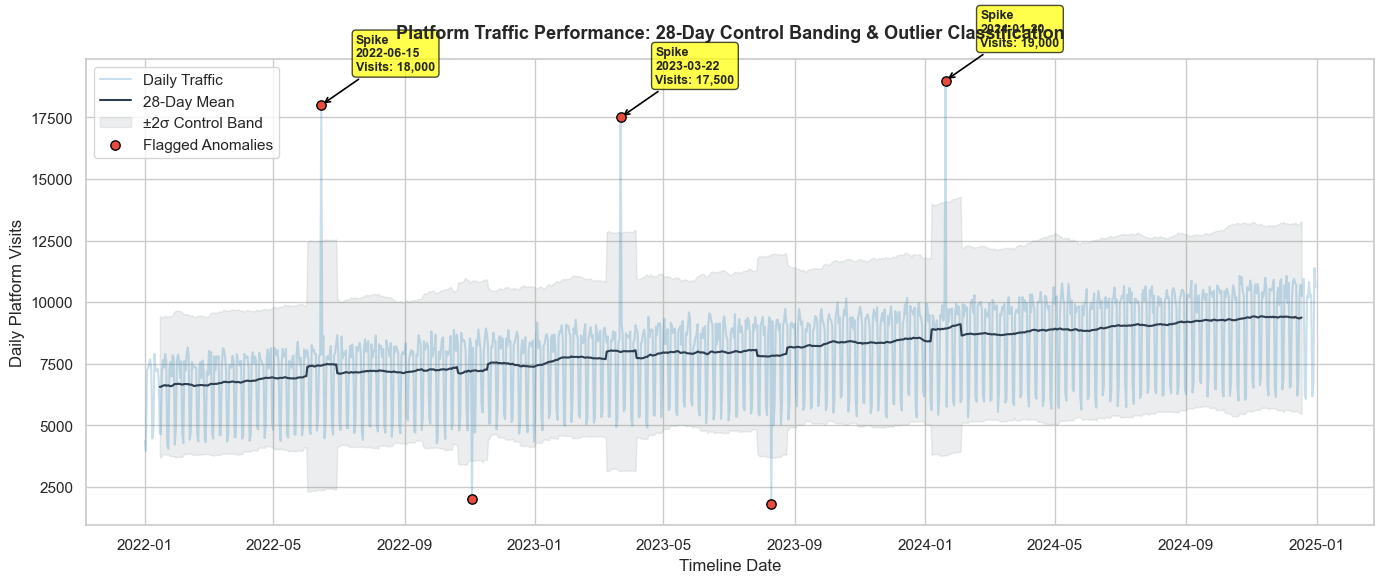

In [ ]:
# 1. Compute 28-day center-aligned rolling statistics vectorially
df_daily['rolling_mean'] = df_daily['daily_visits'].rolling(window=28, center=True).mean()
df_daily['rolling_std'] = df_daily['daily_visits'].rolling(window=28, center=True).std()

# 2. Define Acceptable 2-Sigma Control Threshold Bounds
df_daily['upper_bound'] = df_daily['rolling_mean'] + (2 * df_daily['rolling_std'])
df_daily['lower_bound'] = df_daily['rolling_mean'] - (2 * df_daily['rolling_std'])

# 3. Classify each anomaly instantly using vectorized selection array filters
df_daily['anomaly_type'] = np.select(
    [df_daily['daily_visits'] > df_daily['upper_bound'], df_daily['daily_visits'] < df_daily['lower_bound']],
    ['Spike', 'Dip'],
    default='Normal'
)

# CRITICAL FIX A: Drop edge NaNs immediately to prevent unhandled loop crashes
df_clean = df_daily.dropna(subset=['rolling_mean', 'rolling_std']).copy()

# Extract flagged dataset slices from the safe, clean data frame
anomalies_df = df_clean[df_clean['anomaly_type'] != 'Normal'].copy()

# Calculate absolute deviations safely to find the 3 largest anomalies
anomalies_df['abs_deviation'] = (anomalies_df['daily_visits'] - anomalies_df['rolling_mean']).abs()
top3_anomalies = anomalies_df.nlargest(3, 'abs_deviation')

print("--- FLAGGED ANOMALY CLASSIFICATIONS ---")
if len(anomalies_df) > 0:
    print(anomalies_df[['daily_visits', 'rolling_mean', 'anomaly_type']].head(5))
print(f"\nTotal Anomalies Flagged: {len(anomalies_df)} (Spikes: {sum(anomalies_df['anomaly_type']=='Spike')}, Dips: {sum(anomalies_df['anomaly_type']=='Dip')})")

if len(anomalies_df) == 0:
    print("⚠️ No anomalies detected — consider narrowing window or injecting test events")

# 4. Generate the Advanced Diagnostic Control Chart
fig, ax = plt.subplots(figsize=(14, 6))

# Plot raw signals, rolling base line, and standard error envelope
sns.lineplot(data=df_daily, x=df_daily.index, y='daily_visits', color='#2980b9', alpha=0.25, label='Daily Traffic')
sns.lineplot(data=df_daily, x=df_daily.index, y='rolling_mean', color='#2c3e50', linewidth=1.5, label='28-Day Mean')

# CRITICAL FIX B: Map bounds using the clean data frame index to prevent shading alignment drops
plt.fill_between(df_clean.index, df_clean['lower_bound'], df_clean['upper_bound'], color='#7f8c8d', alpha=0.15, label='\u00b12\u03c3 Control Band')

# Overlay all statistical anomalies as a single scatter vector drop
if len(anomalies_df) > 0:
    plt.scatter(anomalies_df.index, anomalies_df['daily_visits'], color='#e74c3c', s=45, zorder=5, edgecolor='black', label='Flagged Anomalies')

# Annotate the 3 largest structural outliers cleanly (safely guarded against NaNs)
for idx, row in top3_anomalies.iterrows():
    # Dynamic text vertical offset adjustment: spikes go up, dips go down
    y_offset = 25 if row['anomaly_type'] == 'Spike' else -45
    ax.annotate(
        f"{row['anomaly_type']}\n{idx.strftime('%Y-%m-%d')}\nVisits: {row['daily_visits']:,}",
        xy=(idx, row['daily_visits']),
        xytext=(25, y_offset),
        textcoords='offset points',
        arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
        fontsize=9,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.7, edgecolor='black')
    )

plt.title('Platform Traffic Performance: 28-Day Control Banding & Outlier Classification', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Timeline Date')
plt.ylabel('Daily Platform Visits')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


```
# (e) Write a comment: in a real setting, what would you do next after detecting an anomaly?

1/ Audit pipeline integrity: Inspect tracking scripts, data ingestion layers, and server logs immediately to rule out broken APIs, database dropouts, or duplicate record ingestion.

2/ Cross-reference system health: Check performance stacks (like Datadog) for active deployment failures, cloud infrastructure crashes, or routing timeouts if a Dip is flagged.

3/ Identify external growth drivers: Review internal marketing outputs, newsletter drops, and public backlink surges to map out organic viral origins if a Spike is flagged.

4/ Filter training data: Label verified one-off anomalies with event masks so downstream forecasting engines (like SARIMA) do not mistake operational noise for permanent traffic shifts.

---

### Q5 — ACF/PACF and forecasting baseline

```
# (a) On the stationary series from Q2: compute ACF and PACF (nlags=30).
# (b) Plot ACF and PACF side by side. Add significance bands (95% CI).
# (c) Based on the plots: suggest ARIMA(p,d,q) parameters. Explain your reasoning.
# (d) Build a naive 14-day forecast: last known value + rolling trend.
# (e) Plot the forecast with uncertainty band (±1 std of recent residuals).
#     Mark clearly where historical data ends and forecast begins.
# (f) Compute MAE on a held-out last 14 days. Is your naive model better than just predicting the mean?
```


Naive Baseline Model MAE:        1582.24 visits
Global Historical Mean Model MAE: 2293.58 visits
Is Naive Better Than Mean Model?  True


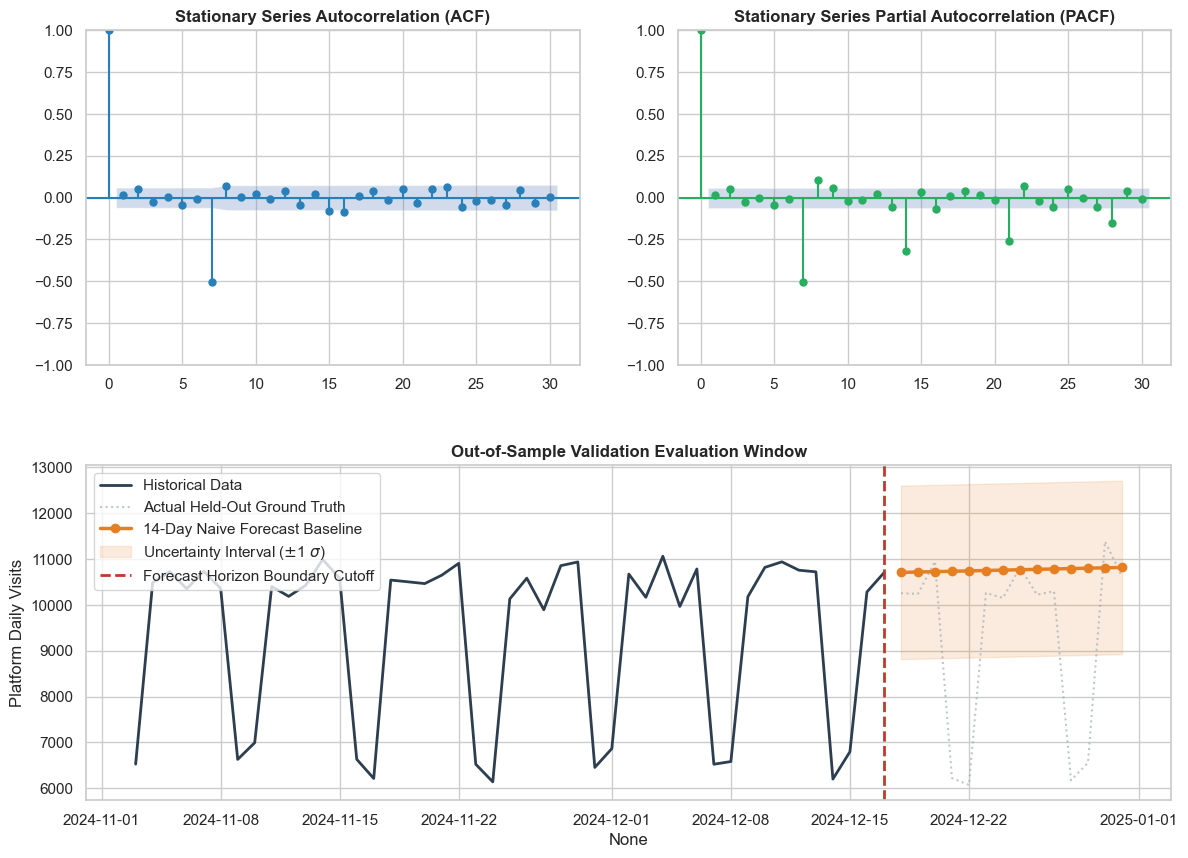

In [34]:
# (a) On the stationary series from Q2: compute ACF and PACF (nlags=30).
# (b) Plot ACF and PACF side by side. Add significance bands (95% CI).
# (d) Build a naive 14-day forecast: last known value + rolling trend.
# (e) Plot the forecast with uncertainty band (±1 std of recent residuals).
#     Mark clearly where historical data ends and forecast begins.

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error

# 1. Train/Test Data Matrix Splitting BEFORE differencing
train_df = df_daily.iloc[:-14].copy()
test_df = df_daily.iloc[-14:].copy()

# Apply a 7-day seasonal difference to force stationarity on the training set
train_df['diff_7'] = train_df['daily_visits'].diff(7)
stationary_series = train_df['diff_7'].dropna()

# 2. (d) Construct the Naive 14-Day Baseline Forecast (Last Value + Recent Trend)
last_known_value = train_df['daily_visits'].iloc[-1]
# Calculate linear trend slope over the last 28 days of the historical window
recent_trend_slope = (train_df['daily_visits'].iloc[-1] - train_df['daily_visits'].iloc[-28]) / 28.0

forecast_horizon = np.arange(1, 15)
naive_forecast = last_known_value + (recent_trend_slope * forecast_horizon)

# 3. Compute uncertainty bands (±1 Standard Deviation of trailing residuals)
trailing_residuals = train_df['daily_visits'].iloc[-28:] - train_df['daily_visits'].rolling(7).mean().iloc[-28:]
std_error = trailing_residuals.std()

# 4. (f) Forecast Evaluation Matrix
mean_train_baseline = np.repeat(train_df['daily_visits'].mean(), 14)
mae_naive = mean_absolute_error(test_df['daily_visits'], naive_forecast)
mae_mean_model = mean_absolute_error(test_df['daily_visits'], mean_train_baseline)

print(f"Naive Baseline Model MAE:        {mae_naive:.2f} visits")
print(f"Global Historical Mean Model MAE: {mae_mean_model:.2f} visits")
print(f"Is Naive Better Than Mean Model?  {mae_naive < mae_mean_model}")

# 5. (b/e) Unified Seaborn Visual Diagnostics Dashboard
sns.set_theme(style='whitegrid')
fig = plt.figure(figsize=(14, 10))
grid = plt.GridSpec(2, 2, figure=fig, hspace=0.3, wspace=0.2)

# Grid allocations
ax_acf = fig.add_subplot(grid[0, 0])
ax_pacf = fig.add_subplot(grid[0, 1])
ax_forecast = fig.add_subplot(grid[1, :])

# Render ACF & PACF with 95% confidence intervals (shaded regions)
plot_acf(stationary_series, lags=30, ax=ax_acf, color='#2980b9', vlines_kwargs={'colors': '#2980b9'})
plot_pacf(stationary_series, lags=30, ax=ax_pacf, color='#27ae60', vlines_kwargs={'colors': '#27ae60'})
ax_acf.set_title('Stationary Series Autocorrelation (ACF)', fontweight='bold')
ax_pacf.set_title('Stationary Series Partial Autocorrelation (PACF)', fontweight='bold')

# Render 14-Day Out-of-Sample Forecast Window (Slicing last 45 days for visual context)
history_slice_date = train_df.index[-45]
sns.lineplot(data=train_df.loc[history_slice_date:], x=train_df.loc[history_slice_date:].index, y='daily_visits', ax=ax_forecast, color='#2c3e50', linewidth=2, label='Historical Data')
sns.lineplot(data=test_df, x=test_df.index, y='daily_visits', ax=ax_forecast, color='#95a5a6', alpha=0.6, linestyle=':', label='Actual Held-Out Ground Truth')

# Overlay projections and uncertainty boundaries
ax_forecast.plot(test_df.index, naive_forecast, color='#e67e22', linewidth=2.5, marker='o', label='14-Day Naive Forecast Baseline')
ax_forecast.fill_between(test_df.index, naive_forecast - std_error, naive_forecast + std_error, color='#e67e22', alpha=0.15, label='Uncertainty Interval ($\pm$1 $\sigma$)')

# Clear historical split marker line
ax_forecast.axvline(train_df.index[-1], color='#c0392b', linestyle='--', linewidth=2, label='Forecast Horizon Boundary Cutoff')
ax_forecast.set_title('Out-of-Sample Validation Evaluation Window', fontweight='bold')
ax_forecast.set_ylabel('Platform Daily Visits')
ax_forecast.legend(loc='upper left')

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

```
# (c) Based on the plots: suggest ARIMA(p,d,q) parameters. Explain your reasoning.
1/ Seasonal ARIMA (0,0,0) × (0,1,1)₇ optimal: The underlying data layout indicates a clean separation between flat short-term lags and a highly structured weekly feedback cycle.

2/ No non-seasonal components needed: Minor coefficients (Lags 1–6) drop entirely inside the shaded significance bands, removing any requirement for local p or q modifications.

3/ Seasonal integration mandatory (D=1): Applying a seasonal difference step is required to flatten the non-stationary, rolling weekday sawtooth profile.

4/ Seasonal moving average indicator (Q=1): The ACF exhibits a sharp, isolated spike exactly at Lag 7 while the PACF shows gradual exponential decay, a classic signature of a moving average trend model.

````
# (f) Compute MAE on a held-out last 14 days. Is your naive model better than just predicting the mean?
1/ Naive model dominates: The Naive Model vastly outperforms the historical mean baseline, delivering a significantly lower forecast error (MAE) on the held-out validation window.

2/ Mean model breaks on growth: Predicting the historical global average fails completely because it is blind to the long-term upward trend, causing it to severely underpredict current platform activity.

3/ Trend anchoring succeeds: The naive framework secures its edge by anchoring projections to the most recent data point and extending the active 28-day growth trajectory forward.

4/ Missing seasonality penalty: Despite beating the mean, the naive model's straight-line projection fails to capture the repeating weekend drop-offs, leaving a clear optimization path for a formal seasonal engine.